# 데이터 정합정 점검 & 전처리

# AI 시대 직업 소멸 위험도 예측 프로젝트
## Part 1. 미국 데이터 정합성 점검 & 마스터 데이터셋 업그레이드

미국 직업 데이터 3종(`master_occupation_dataset.csv`, `occupation.xlsx`, `national_M2025_dl.xlsx`)의 SOC 코드 체계를 점검하고, 2018년 SOC 분류 개정으로 발생한 코드 불일치를 정리한 뒤 하나의 마스터 데이터셋으로 병합한다.

## 1. 데이터 로드

| 변수명 | 파일 | 내용 |
|---|---|---|
| `master_us` | master_occupation_dataset.csv | 798개 직업, GPT-4 노출도 + 2021년 고용/임금 (구버전, 업그레이드 대상) |
| `proj_2034` | occupation.xlsx (Table 1.2) | 2024→2034 고용 전망 (최신) |
| `oews_2025` | national_M2025_dl.xlsx | 2025년 5월 기준 최신 고용/임금 |

In [1]:
import pandas as pd

korea = pd.read_csv("korea_master_outlook.csv")
master_us = pd.read_csv("master_occupation_dataset.csv")
oews_2025 = pd.read_excel('national_M2025_dl.xlsx', sheet_name='national_M2025_dl')
proj_2034 = pd.read_excel('occupation.xlsx', sheet_name='Table 1.2', skiprows=1)

# korea.head()
# master_us.head()
# oews_2025.head()
# proj_2034.head(20)

for name, df in [('korea', korea), ('master_us', master_us), ('oews_2025', oews_2025), ('proj_2034', proj_2034)]:
    print(name, df.shape)

korea (537, 8)
master_us (798, 15)
oews_2025 (1401, 32)
proj_2034 (1117, 16)


## 2. SOC 코드 정합성 1차 점검

세 데이터셋을 합치려면 공통 키(SOC 코드)가 얼마나 일치하는지부터 확인해야 한다.

In [2]:
soc_master = set(master_us['SOC_CODE'])
soc_proj = set(proj_2034['2024 National Employment Matrix code'])
print("master_us만:", len(soc_master - soc_proj))
print('proj_2034만:', len(soc_proj - soc_master))
print('공통:', len(soc_master & soc_proj))

master_us만: 25
proj_2034만: 341
공통: 773


결과: `proj_2034만`이 341개로 비정상적으로 많다. `proj_2034`가 세부직업 행뿐 아니라 대분류 집계 행(`Occupation type` = `Summary`)까지 포함하고 있기 때문이다. 필터링한다.

In [3]:
print(proj_2034['Occupation type'].value_counts())
proj_2034_detailed = proj_2034[proj_2034['Occupation type'] == 'Line item']
print(proj_2034_detailed.shape)

Occupation type
Line item    832
Summary      281
Name: count, dtype: int64
(832, 16)


필터링 후 다시 비교하면 불일치가 341개에서 59개로 줄어든다.

In [4]:
soc_master = set(master_us['SOC_CODE'])
soc_proj = set(proj_2034_detailed['2024 National Employment Matrix code'])
print('master_us만:', len(soc_master - soc_proj))
print('proj_2034만:', len(soc_proj - soc_master))
print('공통:', len(soc_master & soc_proj))


master_us만: 25
proj_2034만: 59
공통: 773


## 3. 불일치 코드의 실제 내용 확인

숫자만 보지 않고 실제 직업명을 직접 확인해 단순 결측인지 분류 개정 때문인지 구분한다.

### 3-1. `master_us`에만 있는 25개 코드

In [5]:
only_master = soc_master - soc_proj
master_us[master_us["SOC_CODE"].isin(only_master)][['SOC_CODE', 'BLS_TITLE']]

,SOC_CODE,BLS_TITLE
38,13-1021,NaN
39,13-1022,NaN
40,13-1023,NaN
58,13-2022,NaN
59,13-2023,NaN
175,21-1011,NaN
178,21-1014,NaN
239,25-2055,NaN
240,25-2056,NaN
255,25-9042,NaN


`BLS_TITLE`이 전부 NaN이다. `ONET_TITLE`은 채워져 있는지 확인한다.

In [6]:
master_us[master_us["SOC_CODE"].isin(only_master)][['SOC_CODE','BLS_TITLE','ONET_TITLE']]

,SOC_CODE,BLS_TITLE,ONET_TITLE
38,13-1021,NaN,"Buyers and Purchasing Agents, Farm Products"
39,13-1022,NaN,"Wholesale and Retail Buyers, Except Farm Products"
40,13-1023,NaN,"Purchasing Agents, Except Wholesale, Retail, a..."
58,13-2022,NaN,Appraisers of Personal and Business Property
59,13-2023,NaN,Appraisers and Assessors of Real Estate
175,21-1011,NaN,Substance Abuse and Behavioral Disorder Counse...
178,21-1014,NaN,Mental Health Counselors
239,25-2055,NaN,"Special Education Teachers, Kindergarten"
240,25-2056,NaN,"Special Education Teachers, Elementary School"
255,25-9042,NaN,"Teaching Assistants, Preschool, Elementary, Mi..."


### 3-2. `proj_2034`에만 있는 59개 코드

In [7]:
only_proj = soc_proj - soc_master
proj_2034_detailed[proj_2034_detailed['2024 National Employment Matrix code'].isin(only_proj)][['2024 National Employment Matrix title','2024 National Employment Matrix code']].sort_values('2024 National Employment Matrix code')

,2024 National Employment Matrix title,2024 National Employment Matrix code
33,"Education administrators, all other",11-9039
53,Buyers and purchasing agents,13-1020
75,Property appraisers and assessors,13-2020
153,"Drafters, all other",17-3019
182,"Life scientists, all other",19-1099
237,"Substance abuse, behavioral disorder, ...",21-1018
238,"Counselors, all other",21-1019
243,"Social workers, all other",21-1029
249,Community and social service specialis...,21-1099
253,"Religious workers, all other",21-2099


**패턴 발견**: 59개 중 9개는 `master_us`의 구코드 여러 개(총 17개 구코드)가 통합된 신코드로 합쳐진 경우다(예: 13-1021/22/23 → 13-1020). 나머지 50개 중 47개는 "~all other" 형태의 잔여 카테고리이고, 3개는 1:1 대응이 불분명한 애매한 코드(47-4091 등)다. `master_us`에도 이미 "all other" 코드가 일부 존재하는데, 그것과는 별개로 새로 생긴 코드인지 확인하기 위해 `master_us`에 "all other" 직업이 있는지 검색한다.

In [8]:
master_us[master_us['BLS_TITLE'].str.contains('all other', case=False, na=False) | master_us['ONET_TITLE'].str.contains('all other', case=False, na=False)]

,SOC_CODE,BLS_TITLE,ONET_TITLE,gpt4_exposure_alpha,gpt4_exposure_beta,gpt4_exposure_gamma,human_rating_beta,emp_2021,mean_annual_wage_2021,median_annual_wage_2021,automation_prob_FreyOsborne2013,pct_emp_change_2020_2030,degree_of_automation_context,importance_of_repeating_same_tasks_context,structured_versus_unstructured_work_context
35,11-9179,"Personal Service Managers, All Other",Fitness and Wellness Coordinators,0.162526,0.452122,0.741718,0.325311,7350.0,59580,60360,NaN,NaN,NaN,NaN,NaN
36,11-9199,"Managers, All Other",Regulatory Affairs Managers,0.071278,0.491267,0.911257,0.465491,497890.0,129710,124650,0.2500,NaN,NaN,NaN,NaN
56,13-1199,"Business Operations Specialists, All Other",Business Continuity Planners,0.224152,0.582841,0.941529,0.537990,1030330.0,79240,74670,0.2300,NaN,NaN,NaN,NaN
71,13-2099,"Financial Specialists, All Other",Financial Quantitative Analysts,0.234644,0.583231,0.931818,0.592445,123200.0,80370,73240,0.3300,NaN,NaN,NaN,NaN
86,15-1299,"Computer Occupations, All Other",Web Administrators,0.476623,0.735786,0.994949,0.596964,370190.0,98180,95270,NaN,9.2,NaN,NaN,NaN
92,15-2099,"Mathematical Science Occupations, All Other",Bioinformatics Technicians,0.766667,0.866667,0.966667,0.650000,3970.0,77960,62460,NaN,NaN,NaN,NaN,NaN
114,17-2199,"Engineers, All Other","Energy Engineers, Except Wind and Solar",0.197453,0.522650,0.847846,0.446173,151940.0,107800,100640,0.0140,2.7,NaN,NaN,NaN
126,17-3029,"Engineering Technologists and Technicians, Exc...",Non-Destructive Testing Specialists,0.055556,0.268774,0.481992,0.260153,73600.0,68290,61950,0.2400,NaN,NaN,NaN,NaN
134,19-1029,"Biological Scientists, All Other",Bioinformatics Scientists,0.252540,0.549212,0.845884,0.460894,47050.0,90010,82530,0.0150,3.7,NaN,NaN,NaN
147,19-2099,"Physical Scientists, All Other",Remote Sensing Scientists and Technologists,0.000000,0.456522,0.913043,0.445652,19680.0,113220,104100,0.4300,1.0,NaN,NaN,NaN


**확인 결과(정정)**: `master_us`에도 "all other" 코드가 23개 이미 존재한다(예: 11-9199 "Managers, All Other"). 다만 이 23개는 신분류(`proj_2034`)에도 동일한 코드로 그대로 존재해서, 애초에 "공통 773개"에 포함되어 매칭이 끝난 상태였다.

문제가 되는 건 `proj_2034` 쪽에만 있는 나머지 47개의 "all other" 코드다(`proj_2034` 전체 "all other" 70개 중 master_us와 겹치지 않는 부분). 이건 `master_us`의 기존 23개 코드가 변형된 게 아니라, 2018년 SOC 분류 개정으로 신분류에서 완전히 새로 생긴 잔여 카테고리다. 구체적으로 어떤 직업들이 묶여 있는지 코드만으로는 알 수 없어 위험도 점수 매칭이 불가능하므로, 이 47개는 분석에서 제외한다.


In [9]:
all_other_master = master_us[
    master_us['BLS_TITLE'].str.contains('all other', case=False, na=False)
]
soc_ao_master = set(all_other_master['SOC_CODE'])

# proj_2034_detailed에서 master_us와 코드가 일치하는 23개만 추출
matched_all_other = proj_2034_detailed[
    proj_2034_detailed['2024 National Employment Matrix code'].isin(soc_ao_master)
][['2024 National Employment Matrix code', '2024 National Employment Matrix title']]

# master_us 쪽 직업명도 같이 붙여서 비교하기 쉽게
result = matched_all_other.merge(
    all_other_master[['SOC_CODE', 'BLS_TITLE']],
    left_on='2024 National Employment Matrix code',
    right_on='SOC_CODE',
    how='left'
)

print(result.shape)
result

(23, 4)


,2024 National Employment Matrix code,2024 National Employment Matrix title,SOC_CODE,BLS_TITLE
0,11-9179,"Personal service managers, all other",11-9179,"Personal Service Managers, All Other"
1,11-9199,"Managers, all other",11-9199,"Managers, All Other"
2,13-1199,"Business operations specialists, all other",13-1199,"Business Operations Specialists, All Other"
3,13-2099,"Financial specialists, all other",13-2099,"Financial Specialists, All Other"
4,15-1299,"Computer occupations, all other",15-1299,"Computer Occupations, All Other"
5,15-2099,"Mathematical science occupations, all other",15-2099,"Mathematical Science Occupations, All Other"
6,17-2199,"Engineers, all other",17-2199,"Engineers, All Other"
7,17-3029,Engineering technologists and technici...,17-3029,"Engineering Technologists and Technicians, Exc..."
8,19-1029,"Biological scientists, all other",19-1029,"Biological Scientists, All Other"
9,19-2099,"Physical scientists, all other",19-2099,"Physical Scientists, All Other"


## 4. SOC 코드 매핑 테이블 작성

"진짜 코드 통합" 케이스만 수동으로 매핑한다. 1:1 대응이 불명확한 케이스(47-4091, 51-2022 등)는 매핑에서 제외한다.

In [10]:
soc_code_mapping = {
    '13-1021': '13-1020', '13-1022': '13-1020', '13-1023': '13-1020',
    '13-2022': '13-2020', '13-2023': '13-2020',
    '21-1011': '21-1018', '21-1014': '21-1019',
    '25-2055': '25-2052', '25-2056': '25-2052',
    '25-9042': '25-9045', '25-9043': '25-9045',
    '29-2011': '29-2010', '29-2012': '29-2010',
    '31-1121': '31-1120', '31-1122': '31-1120',
    '39-7011': '39-7010', '39-7012': '39-7010',
}

## 5. `oews_2025` 레벨 필터링

`oews_2025`(1401행)도 같은 문제가 있는지 점검한다. 먼저 AREA/NAICS 등 컬럼이 필터링 키 역할을 하는지 확인한다.

In [11]:
for col in ['AREA_TYPE','NAICS','I_GROUP','OWN_CODE']:
    print(col, oews_2025[col].value_counts().head())
    print()

AREA_TYPE AREA_TYPE
1    1401
Name: count, dtype: int64

NAICS NAICS
0    1401
Name: count, dtype: int64

I_GROUP I_GROUP
cross-industry    1401
Name: count, dtype: int64

OWN_CODE OWN_CODE
1235    1401
Name: count, dtype: int64



네 컬럼 모두 고유값이 1개뿐이라 필터링 키 역할을 못 한다. 1401행 차이를 만드는 건 `OCC_CODE` 자체의 레벨 구조이므로 확인한다.

In [12]:
print(oews_2025["OCC_CODE"].nunique())
print(oews_2025[["OCC_CODE", "OCC_TITLE"]].head(20))

1394
   OCC_CODE                                          OCC_TITLE
0   00-0000                                    All Occupations
1   11-0000                             Management Occupations
2   11-1000                                     Top Executives
3   11-1010                                   Chief Executives
4   11-1011                                   Chief Executives
5   11-1020                    General and Operations Managers
6   11-1021                    General and Operations Managers
7   11-2000  Advertising, Marketing, Promotions, Public Rel...
8   11-2010                Advertising and Promotions Managers
9   11-2011                Advertising and Promotions Managers
10  11-2020                       Marketing and Sales Managers
11  11-2021                                 Marketing Managers
12  11-2022                                     Sales Managers
13  11-2030          Public Relations and Fundraising Managers
14  11-2032                          Public Relati

OEWS는 보통 `O_GROUP` 컬럼으로 레벨(major/minor/broad/detailed/total)을 구분한다. 존재 여부와 분포를 확인한다.

In [13]:
print([c for c in oews_2025.columns])
print(oews_2025["O_GROUP"].value_counts())

['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY']
O_GROUP
detailed    830
broad       454
minor        94
major        22
total         1
Name: count, dtype: int64


`O_GROUP == 'detailed'`가 830개로 다른 두 데이터셋과 같은 레벨이다. 필터링 후 세 데이터셋의 SOC 코드 일치율을 확인한다.

> 참고: 변수명이 `owes_2025_detail`(오타, `oews`가 아닌 `owes`)로 되어 있는데, 이후 셀들에서 동일하게 참조되는 변수명이라 일관성을 위해 그대로 유지한다.

In [14]:
owes_2025_detail = oews_2025[oews_2025["O_GROUP"] == "detailed"]
print(owes_2025_detail.shape)

soc_owes = set(owes_2025_detail["OCC_CODE"])
soc_proj = set(proj_2034_detailed['2024 National Employment Matrix code'])
soc_master = set(master_us['SOC_CODE'])

print('master_us & proj_2034 & oews_2025 공통:', len(soc_master & soc_proj & soc_owes))
print('proj_2034 & oews_2025 공통 (master_us 제외):', len(soc_proj & soc_owes))


(830, 32)
master_us & proj_2034 & oews_2025 공통: 771
proj_2034 & oews_2025 공통 (master_us 제외): 830


결과: `proj_2034`와 `oews_2025`는 거의 100% 겹친다(둘 다 동일한 최신 분류체계). `master_us`만 매핑이 필요했던 이유가 다시 확인된다.

## 6. 매핑 적용

`master_us`에 매핑된 신코드를 담는 `SOC_CODE_MAPPED` 컬럼을 만든다.

> nunique() 감소 이유: 798행은 그대로지만, 다대일 매핑(예: 13-1021/22/23 → 13-1020)으로 일부 행이 동일한 매핑값을 공유하게 되어 고유값 개수만 줄어든다.

In [15]:
master_us["SOC_CODE_MAPPED"] = master_us["SOC_CODE"].replace(soc_code_mapping)
master_us["SOC_CODE_MAPPED"].nunique()

790

## 7. 세 데이터셋 병합

`SOC_CODE_MAPPED`를 키로 `master_us`(798개, 기준) 기준으로 나머지 두 데이터셋을 left join한다.

In [16]:
merged = master_us.merge(
    proj_2034_detailed, 
    left_on='SOC_CODE_MAPPED', 
    right_on='2024 National Employment Matrix code', 
    how='left'  # master_us 798개 전체를 기준으로 유지
).merge(
    owes_2025_detail,
    left_on='SOC_CODE_MAPPED',
    right_on='OCC_CODE',
    how='left'
)
print(merged.shape)

(798, 64)


### 7-1. 결측치 패턴 확인

In [17]:
merged.isna().sum()

SOC_CODE                 0
BLS_TITLE               26
ONET_TITLE               0
gpt4_exposure_alpha      0
gpt4_exposure_beta       0
                      ... 
A_MEDIAN                10
A_PCT75                 10
A_PCT90                 10
ANNUAL                 741
HOURLY                 794
Length: 64, dtype: int64

**해석**: 핵심 분석 변수는 결측이 거의 없다. `ANNUAL`/`HOURLY`는 OEWS가 직업 특성에 따라 연봉 또는 시급 기준으로만 보고하기 때문에 발생하는 정상적 구조이며, 분석엔 이미 통일된 `A_MEDIAN`을 쓰면 된다. `A_MEDIAN`이 결측인 행을 직접 확인한다.

In [18]:
merged[merged["A_MEDIAN"].isna()][["SOC_CODE", "ONET_TITLE"]]

,SOC_CODE,ONET_TITLE
2,11-1031,Legislators
536,45-3031,Fishing and Hunting Workers
585,47-4091,Segmental Pavers
586,47-4099,Weatherization Installers and Technicians
652,51-2022,Electrical and Electronic Equipment Assemblers
653,51-2023,Electromechanical Equipment Assemblers
658,51-2092,Team Assemblers
751,53-1042,"First-Line Supervisors of Helpers, Laborers, a..."
752,53-1043,First-Line Supervisors of Material-Moving Mach...
753,53-1044,First-Line Supervisors of Passenger Attendants


결측 10개 중 8개는 매핑 테이블에 일부러 포함하지 않은 애매한 코드이고, 나머지 2개(Legislators, Fishing and Hunting Workers)는 신분류 전망 데이터에서 추적되지 않는 직업이다. 798개 중 1.3%로 영향은 제한적이다.

## 8. 컬럼 정리

병합 결과 64개로 늘어난 컬럼 중 중복 메타 정보를 정리한다.

In [19]:
print(merged.columns)

Index(['SOC_CODE', 'BLS_TITLE', 'ONET_TITLE', 'gpt4_exposure_alpha',
       'gpt4_exposure_beta', 'gpt4_exposure_gamma', 'human_rating_beta',
       'emp_2021', 'mean_annual_wage_2021', 'median_annual_wage_2021',
       'automation_prob_FreyOsborne2013', 'pct_emp_change_2020_2030',
       'degree_of_automation_context',
       'importance_of_repeating_same_tasks_context',
       'structured_versus_unstructured_work_context', 'SOC_CODE_MAPPED',
       '2024 National Employment Matrix title',
       '2024 National Employment Matrix code', 'Occupation type',
       'Employment, 2024', 'Employment, 2034',
       'Employment distribution, percent, 2024',
       'Employment distribution, percent, 2034',
       'Employment change, numeric, 2024–34',
       'Employment change, percent, 2024–34', 'Percent self employed, 2024',
       'Occupational openings, 2024–34 annual average',
       'Median annual wage, dollars, 2024[1]',
       'Typical education needed for entry',
       'Work experienc

정리 대상: oews 필터링용 단일값 메타 컬럼(AREA, NAICS 등), 중복 코드/직업명 컬럼(OCC_CODE, '2024 National Employment Matrix code' 등), OOH 링크 텍스트.

In [20]:
drop_cols = ['AREA','AREA_TITLE','AREA_TYPE','PRIM_STATE','NAICS','NAICS_TITLE',
             'I_GROUP','OWN_CODE','O_GROUP','OCC_CODE','OCC_TITLE',
             '2024 National Employment Matrix code',
             'Related Occupational Outlook Handbook (OOH) content xlsx']
merged_clean = merged.drop(columns=drop_cols)
print(merged_clean.shape)
print(merged_clean.columns)

(798, 51)
Index(['SOC_CODE', 'BLS_TITLE', 'ONET_TITLE', 'gpt4_exposure_alpha',
       'gpt4_exposure_beta', 'gpt4_exposure_gamma', 'human_rating_beta',
       'emp_2021', 'mean_annual_wage_2021', 'median_annual_wage_2021',
       'automation_prob_FreyOsborne2013', 'pct_emp_change_2020_2030',
       'degree_of_automation_context',
       'importance_of_repeating_same_tasks_context',
       'structured_versus_unstructured_work_context', 'SOC_CODE_MAPPED',
       '2024 National Employment Matrix title', 'Occupation type',
       'Employment, 2024', 'Employment, 2034',
       'Employment distribution, percent, 2024',
       'Employment distribution, percent, 2034',
       'Employment change, numeric, 2024–34',
       'Employment change, percent, 2024–34', 'Percent self employed, 2024',
       'Occupational openings, 2024–34 annual average',
       'Median annual wage, dollars, 2024[1]',
       'Typical education needed for entry',
       'Work experience in a related occupation',
       'T

### 8-1. 직업명 컬럼 통일

`BLS_TITLE`, `ONET_TITLE`, `'2024 National Employment Matrix title'` 세 직업명 컬럼이 남아있다. 통일 전 실제 값이 얼마나 다른지 확인한다.

In [21]:
# 세 직업명이 얼마나 다른지 확인 (불일치 행만)
check = merged_clean[merged_clean['ONET_TITLE'] != merged_clean['2024 National Employment Matrix title']]
print(check[['ONET_TITLE','2024 National Employment Matrix title']].head(20))

                                           ONET_TITLE  \
0                                    Chief Executives   
1                     General and Operations Managers   
2                                         Legislators   
3                 Advertising and Promotions Managers   
4                                  Marketing Managers   
5                                      Sales Managers   
6                           Public Relations Managers   
7                                Fundraising Managers   
8                    Administrative Services Managers   
9                                 Facilities Managers   
10          Computer and Information Systems Managers   
11                                 Financial Managers   
12                     Industrial Production Managers   
13                                Purchasing Managers   
14  Transportation, Storage, and Distribution Mana...   
15                 Compensation and Benefits Managers   
16                           Hu

불일치는 대소문자 표기 차이일 뿐 실질적 차이는 없다. 결측 없는 `ONET_TITLE`을 대표 컬럼으로 채택하고 나머지는 제거한다.

In [22]:
print('BLS_TITLE' in merged_clean.columns)
print('2024 National Employment Matrix title' in merged_clean.columns)

merged_clean = merged_clean.drop(columns=['BLS_TITLE', '2024 National Employment Matrix title'], errors='ignore')
merged_clean = merged_clean.rename(columns={'ONET_TITLE': 'occupation_title'})
print(merged_clean.shape)
print(merged_clean.columns.tolist())

True
True
(798, 49)
['SOC_CODE', 'occupation_title', 'gpt4_exposure_alpha', 'gpt4_exposure_beta', 'gpt4_exposure_gamma', 'human_rating_beta', 'emp_2021', 'mean_annual_wage_2021', 'median_annual_wage_2021', 'automation_prob_FreyOsborne2013', 'pct_emp_change_2020_2030', 'degree_of_automation_context', 'importance_of_repeating_same_tasks_context', 'structured_versus_unstructured_work_context', 'SOC_CODE_MAPPED', 'Occupation type', 'Employment, 2024', 'Employment, 2034', 'Employment distribution, percent, 2024', 'Employment distribution, percent, 2034', 'Employment change, numeric, 2024–34', 'Employment change, percent, 2024–34', 'Percent self employed, 2024', 'Occupational openings, 2024–34 annual average', 'Median annual wage, dollars, 2024[1]', 'Typical education needed for entry', 'Work experience in a related occupation', 'Typical on-the-job training needed to attain competency in the occupation', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A

## 9. 최종 결과 확인

798행 49컬럼으로 정리된 `merged_clean`이 미국 마스터 데이터셋 업그레이드의 최종 결과물이다. GPT-4 노출도·자동화확률(구버전), 2024→2034 고용전망, 2025년 최신 고용/임금이 모두 결합되어 있으며, 원본 SOC_CODE와 매핑된 SOC_CODE_MAPPED를 둘 다 보존해 분류 개정 추적이 가능하다.

다음 단계(Part 2)에서는 이 테이블을 `korea_master_outlook.csv`와 직업명 기준으로 매칭한다.

In [23]:
merged_clean.head()

,SOC_CODE,occupation_title,gpt4_exposure_alpha,gpt4_exposure_beta,gpt4_exposure_gamma,human_rating_beta,emp_2021,mean_annual_wage_2021,median_annual_wage_2021,automation_prob_FreyOsborne2013,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,11-1011,Chief Executives,0.133333,0.507778,0.882222,0.369444,200480.0,213020,179520,0.015,...,102.88,171.25,244.1,75700,129540,213990,356200,507730,NaN,NaN
1,11-1021,General and Operations Managers,0.000000,0.480769,0.961538,0.384615,2984920.0,115250,97970,0.160,...,50.85,80.42,121.82,50090,72320,105770,167280,253390,NaN,NaN
2,11-1031,Legislators,0.033333,0.400000,0.766667,0.516667,44590.0,57110,37270,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11-2011,Advertising and Promotions Managers,0.000000,0.476744,0.953488,0.546512,22520.0,142860,127150,0.039,...,64.26,96.66,137.62,63300,91370,133660,201050,286240,NaN,NaN
4,11-2021,Marketing Managers,0.062500,0.500000,0.937500,0.578125,278690.0,153440,135030,0.014,...,80.19,104.04,141.16,90260,123020,166790,216410,293610,NaN,NaN


## Korea_Master_Outlook.csv 구조확인

In [24]:
print(korea.shape)
print(korea.columns.tolist())
korea.head()

(537, 8)
['ksco_code', 'occupation_name', 'keco_major_category', 'outlook_2021_2023', 'outlook_2025_if_covered', 'note', 'covered_in_2025_report', 'outlook_changed']


,ksco_code,occupation_name,keco_major_category,outlook_2021_2023,outlook_2025_if_covered,note,covered_in_2025_report,outlook_changed
0,11102,행정부고위공무원,경영·사무·금융·보험직,NaN,NaN,NaN,False,False
1,11201,기업고위임원,경영·사무·금융·보험직,현상태유지,현상태유지,NaN,True,False
2,12101,정부행정관리자,경영·사무·금융·보험직,NaN,NaN,NaN,False,False
3,12201,경영지원관리자,경영·사무·금융·보험직,NaN,NaN,NaN,False,False
4,12301,마케팅·광고·홍보관리자,경영·사무·금융·보험직,NaN,NaN,NaN,False,False


In [25]:
print(korea.isna().sum())
print(korea['covered_in_2025_report'].value_counts())
print(korea['keco_major_category'].value_counts())

ksco_code                    0
occupation_name              0
keco_major_category          0
outlook_2021_2023           61
outlook_2025_if_covered    341
note                       524
covered_in_2025_report       0
outlook_changed              0
dtype: int64
covered_in_2025_report
False    341
True     196
Name: count, dtype: int64
keco_major_category
연구직 및 공학기술직               112
설치·정비·생산직                  92
경영·사무·금융·보험직               84
예술·디자인·방송·스포츠직             62
미용·여행·숙박·음식·경비·청소직         45
보건·의료직                     39
영업·판매·운전·운송직               36
교육·법률·사회복지·경찰·소방직 및 군인     33
건설·채굴직                     24
농림어업직                      10
Name: count, dtype: int64


In [26]:
korea_agri = korea[korea['keco_major_category'] == '농림어업직'][['ksco_code', 'occupation_name']]
print(korea_agri.to_string())

     ksco_code occupation_name
527     901101         곡식작물재배원
528     901201      채소·특용작물재배원
529     901301         과수작물재배원
530     901401    육묘 및 화훼작물재배자
531     901501             조경원
532     902101           낙농종사원
533     902201         가축사육종사원
534     903101  조림·산림경영인 및 벌목원
535     904101             양식원
536     904201         어부 및 해녀


In [27]:
import requests
try:
    r = requests.get('https://huggingface.co', timeout=10)
    print('접속 성공, 상태코드:', r.status_code)
except Exception as e:
    print('접속 실패:', repr(e))

접속 성공, 상태코드: 200


In [28]:
import requests
try:
    r = requests.get('https://huggingface.co', timeout=10)
    print('접속 성공, 상태코드:', r.status_code)
except Exception as e:
    print('접속 실패:', repr(e))

접속 성공, 상태코드: 200


In [29]:
import shutil, os
cache_dir = os.path.expanduser('~/.cache/huggingface')
print('캐시 폴더 존재:', os.path.exists(cache_dir))

캐시 폴더 존재: True


In [30]:
import requests
try:
    r = requests.get(
        'https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config.json',
        timeout=15
    )
    print('상태코드:', r.status_code)
    print(r.text[:300])
except Exception as e:
    print('실패:', repr(e))

상태코드: 200
{
  "_name_or_path": "old_models/paraphrase-multilingual-MiniLM-L12-v2/0_Transformer",
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 384,
  "initializer_range"


In [31]:
import shutil
total, used, free = shutil.disk_usage("/")
print(f"전체: {total // (2**30)} GB")
print(f"사용중: {used // (2**30)} GB")
print(f"여유: {free // (2**30)} GB")

전체: 228 GB
사용중: 226 GB
여유: 2 GB


In [32]:
from huggingface_hub import snapshot_download
try:
    path = snapshot_download('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
    print('다운로드 성공:', path)
except Exception as e:
    print('다운로드 실패:', repr(e))

Fetching 28 files:   0%|          | 0/28 [00:00<?, ?it/s]

다운로드 성공: /Users/brave/.cache/huggingface/hub/models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2/snapshots/e8f8c211226b894fcb81acc59f3b34ba3efd5f42


In [33]:
!pip install -U sentence-transformers huggingface_hub
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 번역 없이 한국어 원문 그대로 사용
korea_names_ko = ['곡식작물재배원', '채소·특용작물재배원', '과수작물재배원',
                   '육묘 및 화훼작물재배자', '조경원', '낙농종사원',
                   '가축사육종사원', '조림·산림경영인 및 벌목원', '양식원', '어부 및 해녀']

us_titles = [
    'First-Line Supervisors of Farming, Fishing, and Forestry Workers',
    'Agricultural Inspectors', 'Animal Breeders',
    'Graders and Sorters, Agricultural Products',
    'Agricultural Equipment Operators',
    'Farmworkers and Laborers, Crop, Nursery, and Greenhouse',
    'Farmworkers, Farm, Ranch, and Aquacultural Animals',
    'Fishing and Hunting Workers',
    'Forest and Conservation Workers', 'Fallers',
    'Logging Equipment Operators', 'Log Graders and Scalers',
    'Landscaping and Groundskeeping Workers',
]

korea_emb = model.encode(korea_names_ko)
us_emb = model.encode(us_titles)

sim_matrix = cosine_similarity(korea_emb, us_emb)

for i, name in enumerate(korea_names_ko):
    best_idx = sim_matrix[i].argmax()
    print(f"{name} → {us_titles[best_idx]} (유사도 {sim_matrix[i][best_idx]:.3f})")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 2.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.20.0
    Uninstalling huggingface_hub-1.20.0:
      Successfully uninstalled huggingface_hub-1.20.0

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

곡식작물재배원 → Farmworkers and Laborers, Crop, Nursery, and Greenhouse (유사도 0.644)
채소·특용작물재배원 → Graders and Sorters, Agricultural Products (유사도 0.569)
과수작물재배원 → Farmworkers and Laborers, Crop, Nursery, and Greenhouse (유사도 0.689)
육묘 및 화훼작물재배자 → Farmworkers and Laborers, Crop, Nursery, and Greenhouse (유사도 0.685)
조경원 → Agricultural Inspectors (유사도 0.523)
낙농종사원 → Agricultural Inspectors (유사도 0.579)
가축사육종사원 → Farmworkers, Farm, Ranch, and Aquacultural Animals (유사도 0.597)
조림·산림경영인 및 벌목원 → Forest and Conservation Workers (유사도 0.795)
양식원 → Fallers (유사도 0.513)
어부 및 해녀 → Farmworkers, Farm, Ranch, and Aquacultural Animals (유사도 0.448)


In [34]:
us_titles_all = master_us['ONET_TITLE'].dropna().tolist()
print(len(us_titles_all))

798


In [35]:
korea_names_ko = korea[korea['keco_major_category'] == '농림어업직']['occupation_name'].tolist()
korea_names_ko
korea_emb = model.encode(korea_names_ko)
us_emb = model.encode(us_titles_all)

sim_matrix = cosine_similarity(korea_emb, us_emb)

for i, name in enumerate(korea_names_ko):
    best_idx = sim_matrix[i].argmax()
    print(f"{name} → {us_titles_all[best_idx]} (유사도 {sim_matrix[i][best_idx]:.3f})")

곡식작물재배원 → Agricultural Engineers (유사도 0.739)
채소·특용작물재배원 → Agricultural Engineers (유사도 0.638)
과수작물재배원 → Agricultural Engineers (유사도 0.691)
육묘 및 화훼작물재배자 → Farmworkers and Laborers, Crop, Nursery, and Greenhouse (유사도 0.685)
조경원 → Concierges (유사도 0.734)
낙농종사원 → Roofers (유사도 0.645)
가축사육종사원 → Concierges (유사도 0.623)
조림·산림경영인 및 벌목원 → Foresters (유사도 0.834)
양식원 → Concierges (유사도 0.749)
어부 및 해녀 → Orthodontists (유사도 0.576)


In [36]:
idx = korea_names_ko.index('조경원')
target_idx = us_titles_all.index('Landscaping and Groundskeeping Workers')

print("798개 후보일 때 '조경원' vs 'Landscaping...' 유사도:", round(sim_matrix[idx][target_idx], 3))
print("798개 중 1위였던 'Concierges' 유사도:", round(sim_matrix[idx].max(), 3))

798개 후보일 때 '조경원' vs 'Landscaping...' 유사도: 0.338
798개 중 1위였던 'Concierges' 유사도: 0.734


In [37]:
import numpy as np

for i, name in enumerate(korea_names_ko):
    top5_idx = np.argsort(sim_matrix[i])[::-1][:5]
    print(f"\n{name}")
    for rank, idx2 in enumerate(top5_idx, 1):
        print(f"  {rank}위: {us_titles_all[idx2]} ({sim_matrix[i][idx2]:.3f})")


곡식작물재배원
  1위: Agricultural Engineers (0.739)
  2위: Agricultural Technicians (0.717)
  3위: Farmworkers and Laborers, Crop, Nursery, and Greenhouse (0.644)
  4위: Agricultural Equipment Operators (0.623)
  5위: Agricultural Inspectors (0.615)

채소·특용작물재배원
  1위: Agricultural Engineers (0.638)
  2위: Agricultural Technicians (0.614)
  3위: Graders and Sorters, Agricultural Products (0.569)
  4위: Agricultural Inspectors (0.558)
  5위: Farmworkers and Laborers, Crop, Nursery, and Greenhouse (0.553)

과수작물재배원
  1위: Agricultural Engineers (0.691)
  2위: Farmworkers and Laborers, Crop, Nursery, and Greenhouse (0.689)
  3위: Agricultural Technicians (0.644)
  4위: Farmers, Ranchers, and Other Agricultural Managers (0.598)
  5위: Agricultural Inspectors (0.594)

육묘 및 화훼작물재배자
  1위: Farmworkers and Laborers, Crop, Nursery, and Greenhouse (0.685)
  2위: Agricultural Engineers (0.627)
  3위: Farmers, Ranchers, and Other Agricultural Managers (0.599)
  4위: Agricultural Technicians (0.595)
  5위: Farmworkers, Farm,

In [38]:
print(sim_matrix.shape)
print(len(korea_names_ko), len(us_titles_all))

(10, 798)
10 798


In [39]:
emb_alone = model.encode(['Landscaping and Groundskeeping Workers'])
emb_from_batch = us_emb[us_titles_all.index('Landscaping and Groundskeeping Workers')]

import numpy as np
print("두 벡터가 똑같은지:", np.allclose(emb_alone[0], emb_from_batch))
print("코사인 유사도(둘이 얼마나 비슷한지):", cosine_similarity([emb_alone[0]], [emb_from_batch])[0][0])

두 벡터가 똑같은지: False
코사인 유사도(둘이 얼마나 비슷한지): 0.99999994


In [40]:
!pip install rapidfuzz


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [41]:
# ============================================================
# 한미 직업명 하이브리드 매칭 파이프라인
# rapidfuzz(문자열 유사도) + 임베딩(의미 유사도) 결합
# ============================================================

import pandas as pd
import numpy as np
from rapidfuzz import fuzz, process
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 0. 데이터 준비
# ------------------------------------------------------------
master_us = pd.read_csv('master_occupation_dataset.csv')
us_titles_all = master_us['ONET_TITLE'].dropna().tolist()

korea = pd.read_csv('korea_master_outlook.csv')

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 미국 직업명은 한 번만 임베딩해두고 재사용 (798개, 매번 다시 계산하면 느림)
us_emb_all = model.encode(us_titles_all)


# ------------------------------------------------------------
# 1. rapidfuzz Top-N 함수
#    - 영문 번역이 필요. 직접 입력한 딕셔너리를 인자로 받음
# ------------------------------------------------------------
def get_rapidfuzz_topn(korea_name_en, us_titles, scorer=fuzz.partial_ratio, n=3):
    """문자열 유사도 기준 Top-N 후보를 반환한다."""
    results = process.extract(korea_name_en, us_titles, scorer=scorer, limit=n)
    return [title for title, score, idx in results], [round(score, 1) for title, score, idx in results]


# ------------------------------------------------------------
# 2. 임베딩 Top-N 함수
#    - 한국어 원문을 그대로 사용 (번역 불필요, 다국어 모델 특성 활용)
# ------------------------------------------------------------
def get_embedding_topn(korea_name_ko, us_titles, us_emb, model, n=5):
    """의미 임베딩 유사도 기준 Top-N 후보를 반환한다."""
    korea_emb = model.encode([korea_name_ko])
    sim = cosine_similarity(korea_emb, us_emb)[0]
    top_idx = np.argsort(sim)[::-1][:n]
    return [us_titles[i] for i in top_idx], [round(sim[i], 3) for i in top_idx]


# ------------------------------------------------------------
# 3. 두 방법을 결합해 신뢰도(confidence)를 매기는 함수
# ------------------------------------------------------------
def hybrid_match(korea_name_ko, korea_name_en, us_titles, us_emb, model,
                  rapidfuzz_n=3, embedding_n=5):
    fuzz_titles, fuzz_scores = get_rapidfuzz_topn(korea_name_en, us_titles, n=rapidfuzz_n)
    emb_titles, emb_scores = get_embedding_topn(korea_name_ko, us_titles, us_emb, model, n=embedding_n)

    overlap = set(fuzz_titles) & set(emb_titles)

    if overlap:
        # 교집합이 있으면: 두 방법이 모두 인정한 후보 중,
        # 임베딩 유사도가 더 높은 순으로 정렬해 1순위를 정한다
        overlap_ranked = sorted(
            overlap,
            key=lambda t: emb_scores[emb_titles.index(t)],
            reverse=True
        )
        best_match = overlap_ranked[0]
        confidence = "높음(자동 확정)"
    else:
        # 교집합이 없으면: 사람 검토(또는 Claude API 보조) 대상
        best_match = None
        confidence = "낮음(수동 검토 필요)"

    return {
        'korea_name': korea_name_ko,
        'korea_name_en': korea_name_en,
        'rapidfuzz_top3': list(zip(fuzz_titles, fuzz_scores)),
        'embedding_top5': list(zip(emb_titles, emb_scores)),
        'overlap': list(overlap),
        'best_match': best_match,
        'confidence': confidence,
    }


# ------------------------------------------------------------
# 4. 농림어업직 10개에 적용
# ------------------------------------------------------------
korea_agri_en = {
    '곡식작물재배원': 'Crop Farmworker',
    '채소·특용작물재배원': 'Vegetable and Specialty Crop Farmworker',
    '과수작물재배원': 'Fruit Crop Farmworker',
    '육묘 및 화훼작물재배자': 'Nursery and Floriculture Grower',
    '조경원': 'Landscaper',
    '낙농종사원': 'Dairy Farm Worker',
    '가축사육종사원': 'Livestock Worker',
    '조림·산림경영인 및 벌목원': 'Forestry Manager and Logger',
    '양식원': 'Aquaculture Worker',
    '어부 및 해녀': 'Fisher and Diver',
}

results = []
for ko_name, en_name in korea_agri_en.items():
    r = hybrid_match(ko_name, en_name, us_titles_all, us_emb_all, model)
    results.append(r)
    print(f"\n{'='*60}")
    print(f"한국 직업명: {r['korea_name']} ({r['korea_name_en']})")
    print(f"rapidfuzz Top-3: {r['rapidfuzz_top3']}")
    print(f"embedding Top-5: {r['embedding_top5']}")
    print(f"교집합: {r['overlap']}")
    print(f"최종 매칭: {r['best_match']} [{r['confidence']}]")

results_df = pd.DataFrame(results)
results_df.to_csv('agri_hybrid_matching.csv', index=False, encoding='utf-8-sig')
print(f"\n\n자동 확정: {(results_df['confidence']=='높음(자동 확정)').sum()}개")
print(f"수동 검토 필요: {(results_df['confidence']=='낮음(수동 검토 필요)').sum()}개")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


한국 직업명: 곡식작물재배원 (Crop Farmworker)
rapidfuzz Top-3: [('Farmworkers and Laborers, Crop, Nursery, and Greenhouse', 80.0), ('Farmworkers, Farm, Ranch, and Aquacultural Animals', 80.0), ('Proofreaders and Copy Markers', 66.7)]
embedding Top-5: [('Agricultural Engineers', 0.739), ('Agricultural Technicians', 0.717), ('Farmworkers and Laborers, Crop, Nursery, and Greenhouse', 0.644), ('Agricultural Equipment Operators', 0.623), ('Agricultural Inspectors', 0.615)]
교집합: ['Farmworkers and Laborers, Crop, Nursery, and Greenhouse']
최종 매칭: Farmworkers and Laborers, Crop, Nursery, and Greenhouse [높음(자동 확정)]

한국 직업명: 채소·특용작물재배원 (Vegetable and Specialty Crop Farmworker)
rapidfuzz Top-3: [('Bakers', 66.7), ('Animal Control Workers', 60.5), ('Health Education Specialists', 60.0)]
embedding Top-5: [('Agricultural Engineers', 0.638), ('Agricultural Technicians', 0.614), ('Graders and Sorters, Agricultural Products', 0.569), ('Agricultural Inspectors', 0.558), ('Farmworkers and Laborers, Crop, Nursery, an

In [42]:
!pip install deep_translator


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [43]:
# ============================================================
# 한미 직업명 하이브리드 매칭 파이프라인 (537개 전체)
# 1) deep-translator로 한국어 직업명 537개 자동 번역
# 2) rapidfuzz(번역문 기준) + 임베딩(한국어 원문 기준) Top-N 비교
# 3) 교집합 있으면 자동 확정 / 없으면 수동 검토 대상으로 분리
# ============================================================

import pandas as pd
import numpy as np
import time
from rapidfuzz import fuzz, process
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from deep_translator import GoogleTranslator

# ------------------------------------------------------------
# 0. 데이터 준비
# ------------------------------------------------------------
master_us = pd.read_csv('master_occupation_dataset.csv')
us_titles_all = master_us['ONET_TITLE'].dropna().tolist()

korea = pd.read_csv('korea_master_outlook.csv')

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
us_emb_all = model.encode(us_titles_all)  # 798개, 한 번만 계산해서 재사용


# ------------------------------------------------------------
# 1. 537개 직업명 자동 번역
#    - 무료 엔드포인트라 너무 빨리 연속 호출하면 차단될 수 있어
#      약간의 지연(sleep)을 둔다
#    - 실패하는 항목은 None으로 남기고 나중에 따로 처리
# ------------------------------------------------------------
def translate_korea_names(korea_names, sleep_sec=0.3):
    translator = GoogleTranslator(source='ko', target='en')
    translations = []
    for i, name in enumerate(korea_names):
        try:
            en = translator.translate(name)
        except Exception as e:
            print(f"  [번역 실패] {name}: {e}")
            en = None
        translations.append(en)
        time.sleep(sleep_sec)
        if (i + 1) % 50 == 0:
            print(f"  진행: {i+1}/{len(korea_names)}")
    return translations


print("1단계: 537개 직업명 번역 시작...")
korea['occupation_name_en'] = translate_korea_names(korea['occupation_name'].tolist())

# 번역 실패한 항목 확인
n_failed = korea['occupation_name_en'].isna().sum()
print(f"번역 실패 개수: {n_failed}")

# 중간 저장 (번역은 시간이 걸리므로, 한 번 해두면 재사용 가능하게)
korea.to_csv('korea_with_translation.csv', index=False, encoding='utf-8-sig')
print("번역 결과를 'korea_with_translation.csv'에 저장했습니다.")


# ------------------------------------------------------------
# 2. rapidfuzz / 임베딩 Top-N 함수 (이전과 동일)
# ------------------------------------------------------------
def get_rapidfuzz_topn(korea_name_en, us_titles, scorer=fuzz.partial_ratio, n=3):
    if korea_name_en is None:
        return [], []
    results = process.extract(korea_name_en, us_titles, scorer=scorer, limit=n)
    return [title for title, score, idx in results], [round(score, 1) for title, score, idx in results]


def get_embedding_topn(korea_name_ko, us_titles, us_emb, model, n=5):
    korea_emb = model.encode([korea_name_ko])
    sim = cosine_similarity(korea_emb, us_emb)[0]
    top_idx = np.argsort(sim)[::-1][:n]
    return [us_titles[i] for i in top_idx], [round(sim[i], 3) for i in top_idx]


def hybrid_match(korea_name_ko, korea_name_en, us_titles, us_emb, model,
                  rapidfuzz_n=3, embedding_n=5):
    fuzz_titles, fuzz_scores = get_rapidfuzz_topn(korea_name_en, us_titles, n=rapidfuzz_n)
    emb_titles, emb_scores = get_embedding_topn(korea_name_ko, us_titles, us_emb, model, n=embedding_n)

    overlap = set(fuzz_titles) & set(emb_titles)

    if overlap:
        overlap_ranked = sorted(
            overlap,
            key=lambda t: emb_scores[emb_titles.index(t)],
            reverse=True
        )
        best_match = overlap_ranked[0]
        confidence = "높음(자동 확정)"
    else:
        best_match = None
        confidence = "낮음(수동 검토 필요)"

    return {
        'ksco_code': None,  # 아래 3단계에서 채움
        'korea_name': korea_name_ko,
        'korea_name_en': korea_name_en,
        'keco_major_category': None,  # 아래 3단계에서 채움
        'rapidfuzz_top3': fuzz_titles,
        'embedding_top5': emb_titles,
        'overlap': list(overlap),
        'best_match': best_match,
        'confidence': confidence,
    }


# ------------------------------------------------------------
# 3. 537개 전체에 하이브리드 매칭 적용
#    - embedding은 한국어 537개를 한 번에 인코딩해서 속도를 높인다
# ------------------------------------------------------------
print("\n2단계: 537개 전체 하이브리드 매칭 시작...")

korea_emb_all = model.encode(korea['occupation_name'].tolist())  # 537개 한 번에 인코딩
sim_matrix_all = cosine_similarity(korea_emb_all, us_emb_all)     # (537, 798)

all_results = []
for i, row in korea.iterrows():
    ko_name = row['occupation_name']
    en_name = row['occupation_name_en']

    # rapidfuzz Top-3 (번역문 기준)
    fuzz_titles, fuzz_scores = get_rapidfuzz_topn(en_name, us_titles_all, n=3)

    # embedding Top-5 (미리 계산한 sim_matrix_all에서 행 i만 사용 — 매번 인코딩하지 않아 빠름)
    top_idx = np.argsort(sim_matrix_all[i])[::-1][:5]
    emb_titles = [us_titles_all[j] for j in top_idx]
    emb_scores = [round(sim_matrix_all[i][j], 3) for j in top_idx]

    overlap = set(fuzz_titles) & set(emb_titles)
    if overlap:
        overlap_ranked = sorted(overlap, key=lambda t: emb_scores[emb_titles.index(t)], reverse=True)
        best_match = overlap_ranked[0]
        confidence = "높음(자동 확정)"
    else:
        best_match = None
        confidence = "낮음(수동 검토 필요)"

    all_results.append({
        'ksco_code': row['ksco_code'],
        'korea_name': ko_name,
        'korea_name_en': en_name,
        'keco_major_category': row['keco_major_category'],
        'rapidfuzz_top3': fuzz_titles,
        'embedding_top5': emb_titles,
        'overlap': list(overlap),
        'best_match': best_match,
        'confidence': confidence,
    })

    if (i + 1) % 50 == 0:
        print(f"  진행: {i+1}/{len(korea)}")

results_df = pd.DataFrame(all_results)
results_df.to_csv('korea_us_hybrid_matching_full.csv', index=False, encoding='utf-8-sig')

# ------------------------------------------------------------
# 4. 결과 요약
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("전체 결과 요약")
print("=" * 60)
print(results_df['confidence'].value_counts())
print()
print("카테고리별 자동 확정 비율:")
summary = results_df.groupby('keco_major_category')['confidence'].apply(
    lambda x: (x == '높음(자동 확정)').mean()
).sort_values(ascending=False)
print(summary)

print("\n결과가 'korea_us_hybrid_matching_full.csv'에 저장되었습니다.")
print("'낮음(수동 검토 필요)' 행만 따로 보려면:")
print("  manual_review = results_df[results_df['confidence'] == '낮음(수동 검토 필요)']")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

1단계: 537개 직업명 번역 시작...
  진행: 50/537
  진행: 100/537
  진행: 150/537
  진행: 200/537
  진행: 250/537
  진행: 300/537
  진행: 350/537
  진행: 400/537
  진행: 450/537
  [번역 실패] 도장원(도장기조작원): ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
  [번역 실패] 타이어·고무제품생산기계조작원: 타이어·고무제품생산기계조작원 --> No translation was found using the current translator. Try another translator?
  [번역 실패] 플라스틱제품생산기계조작원: 플라스틱제품생산기계조작원 --> No translation was found using the current translator. Try another translator?
  진행: 500/537
번역 실패 개수: 3
번역 결과를 'korea_with_translation.csv'에 저장했습니다.

2단계: 537개 전체 하이브리드 매칭 시작...
  진행: 50/537
  진행: 100/537
  진행: 150/537
  진행: 200/537
  진행: 250/537
  진행: 300/537
  진행: 350/537
  진행: 400/537
  진행: 450/537
  진행: 500/537

전체 결과 요약
confidence
낮음(수동 검토 필요)    322
높음(자동 확정)       215
Name: count, dtype: int64

카테고리별 자동 확정 비율:
keco_major_category
보건·의료직                    0.564103
연구직 및 공학기술직               0.562500
건설·채굴직                    0.458333
예술·디자인·방송·스포츠직      

In [44]:
# =============================================================================
# AI 시대 직업 소멸 위험도 예측 — 매칭 → 위험점수 파이프라인
# -----------------------------------------------------------------------------
# 노트북 (6:18/6:19) "하이브리드 매칭"까지 이후의 작업을 하나로 정리한 코드.
# 실행하면 아래 산출물을 재생성한다:
#   - merged_clean.csv              (미국 마스터 최신본)
#   - korea_us_gated_matching.csv   (게이팅 매칭 결과)
#   - matching_review_queue.csv     (검토 필요 92개)
#   - korea_master_analysis.csv     (EDA용 단일 마스터 테이블)  ⭐ 최종 산출물
#
# 의존: pandas, numpy, scikit-learn, sentence-transformers, rapidfuzz
# =============================================================================

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from rapidfuzz import fuzz


# =============================================================================
# STEP 0. 데이터 로드
# =============================================================================
korea       = pd.read_csv("korea_master_outlook.csv")          # 한국 537개 + KECO코드 + 전망
master_us   = pd.read_csv("master_occupation_dataset.csv")     # 미국 798개 + AI지표(구버전 임금/고용)
oews_2025   = pd.read_excel("national_M2025_dl.xlsx", sheet_name="national_M2025_dl")  # 2025 최신 임금
proj_2034   = pd.read_excel("occupation.xlsx", sheet_name="Table 1.2", skiprows=1)     # 2024-34 고용전망
# 한국어 직업명 537개의 영문 번역(deep-translator)은 노트북 셀 67에서 이미 수행됨 → 파일 로드
korea_trans = pd.read_csv("korea_with_translation.csv")        # occupation_name_en 포함


# =============================================================================
# STEP 1. 미국 데이터 3종 병합  (노트북 Part 1 로직 재현 → CSV 영속화)
# -----------------------------------------------------------------------------
# 2018 SOC 분류 개정으로 master_us의 구코드 일부가 신코드로 통합됨 → 매핑표로 정렬 후 병합.
# =============================================================================

# proj_2034: 세부직업(Line item)만, oews: detailed 레벨만 → 세 데이터셋 레벨 일치
proj_det = proj_2034[proj_2034["Occupation type"] == "Line item"].copy()
oews_det = oews_2025[oews_2025["O_GROUP"] == "detailed"].copy()

# 구코드 → 신코드 매핑 (master_us만 구분류라 정렬 필요)
soc_code_mapping = {
    "13-1021": "13-1020", "13-1022": "13-1020", "13-1023": "13-1020",
    "13-2022": "13-2020", "13-2023": "13-2020",
    "21-1011": "21-1018", "21-1014": "21-1019",
    "25-2055": "25-2052", "25-2056": "25-2052",
    "25-9042": "25-9045", "25-9043": "25-9045",
    "29-2011": "29-2010", "29-2012": "29-2010",
    "31-1121": "31-1120", "31-1122": "31-1120",
    "39-7011": "39-7010", "39-7012": "39-7010",
}
master_us["SOC_CODE_MAPPED"] = master_us["SOC_CODE"].replace(soc_code_mapping)

merged = (
    master_us
    .merge(proj_det, left_on="SOC_CODE_MAPPED",
           right_on="2024 National Employment Matrix code", how="left")  # master_us 798개 기준 유지
    .merge(oews_det, left_on="SOC_CODE_MAPPED", right_on="OCC_CODE", how="left")
)

# 필터링용 단일값 메타 컬럼 / 중복 코드·직업명 컬럼 제거
drop_cols = [
    "AREA", "AREA_TITLE", "AREA_TYPE", "PRIM_STATE", "NAICS", "NAICS_TITLE",
    "I_GROUP", "OWN_CODE", "O_GROUP", "OCC_CODE", "OCC_TITLE",
    "2024 National Employment Matrix code",
    "Related Occupational Outlook Handbook (OOH) content xlsx",
    "BLS_TITLE", "2024 National Employment Matrix title",
]
merged_clean = (
    merged.drop(columns=[c for c in drop_cols if c in merged.columns])
          .rename(columns={"ONET_TITLE": "occupation_title"})
)
merged_clean.to_csv("merged_clean.csv", index=False, encoding="utf-8-sig")
print(f"[STEP 1] merged_clean: {merged_clean.shape} → merged_clean.csv")


# =============================================================================
# STEP 2. 한미 직업 매칭  (카테고리 게이팅 + 이중언어 임베딩)
# -----------------------------------------------------------------------------
# 기존 교집합 매칭의 문제: 분야를 무시해 조경원→Concierges 같은 고유사도 오매칭 발생.
# 개선: ① 한국 대분류 → 미국 SOC 대분류로 후보 제한(게이팅)
#       ② max(한국어 임베딩, 영어번역 임베딩) → 작물재배는 한국어가, 동물·수산은 영어가 강함
# =============================================================================

# --- 게이팅 맵: KECO 대분류 10개 → 미국 SOC 대분류(2자리) ---
GATE = {
    "연구직 및 공학기술직":               ["15", "17", "19"],
    "설치·정비·생산직":                  ["49", "51"],
    "경영·사무·금융·보험직":             ["11", "13", "43"],
    "예술·디자인·방송·스포츠직":         ["27"],
    "미용·여행·숙박·음식·경비·청소직":   ["35", "37", "39", "33"],
    "보건·의료직":                       ["29", "31"],
    "영업·판매·운전·운송직":             ["41", "53"],
    "교육·법률·사회복지·경찰·소방직 및 군인": ["25", "23", "21", "33"],
    "건설·채굴직":                       ["47"],
    "농림어업직":                        ["45", "37"],   # 37=조경(녹지관리) 포함
}
# 전문직 카테고리: 보조직/기사로 매칭되면 '레벨 오류' 의심 플래그
PROF_CATS   = {"보건·의료직", "연구직 및 공학기술직", "교육·법률·사회복지·경찰·소방직 및 군인"}
LEVEL_WORDS = r"Assistant|Technician|Aide|Helper|Clerk"

# --- 임베딩 (다국어 모델: 한국어 직접 인코딩 가능) ---
m = master_us.dropna(subset=["ONET_TITLE"]).reset_index(drop=True)
m["soc2"]  = m["SOC_CODE"].str[:2]
us_titles  = m["ONET_TITLE"].tolist()
us_soc2    = m["soc2"].tolist()

model   = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
us_emb  = model.encode(us_titles, show_progress_bar=False)
ko_emb  = model.encode(korea_trans["occupation_name"].fillna("").tolist(),    show_progress_bar=False)
en_emb  = model.encode(korea_trans["occupation_name_en"].fillna("").tolist(), show_progress_bar=False)

# 한국어/영어 임베딩 유사도 중 강한 신호 채택
sim_max = np.maximum(cosine_similarity(ko_emb, us_emb),
                     cosine_similarity(en_emb, us_emb))

HI, MID = 0.60, 0.45   # 신뢰도 임계값
rows = []
for i, row in korea_trans.iterrows():
    cat     = row["keco_major_category"]
    allowed = GATE.get(cat, [])
    gate_idx = [j for j, s2 in enumerate(us_soc2) if s2 in allowed]

    fallback = False
    if gate_idx:
        order = sorted(gate_idx, key=lambda j: -sim_max[i, j])   # 게이트 안 후보 정렬
        # 게이트 최고점이 너무 낮으면 전체 풀에서 재탐색(fallback)
        if sim_max[i, order[0]] < MID:
            full = int(sim_max[i].argmax())
            if sim_max[i, full] > sim_max[i, order[0]] + 0.05:
                order, fallback = [full] + order, True
    else:
        order, fallback = [int(sim_max[i].argmax())], True

    top3  = order[:3]
    bj    = top3[0]
    score = float(sim_max[i, bj])
    best  = us_titles[bj]
    rf    = float(fuzz.token_sort_ratio(str(row["occupation_name_en"]), best))  # 문자열 일치(영어)

    # 신뢰도: 임베딩 높거나(임계 HI) / 중간이지만 rapidfuzz도 동의(>=70)
    if score >= HI or (score >= MID and rf >= 70):
        conf = "높음(자동확정)"
    elif score >= MID:
        conf = "중간(검토권장)"
    else:
        conf = "낮음(수동검토)"

    # 전문직인데 보조/기사로 매칭 → 레벨오류 의심 (단 한국어 직급어가 assistant/technician이면 사실 정답)
    level_err = (cat in PROF_CATS) and bool(
        pd.Series([best]).str.contains(LEVEL_WORDS, case=False).iloc[0])

    rows.append(dict(
        ksco_code=row["ksco_code"], korea_name=row["occupation_name"],
        korea_name_en=row["occupation_name_en"], keco_major_category=cat,
        best_match=best, best_soc=m.iloc[bj]["SOC_CODE"], sim=round(score, 3),
        rapidfuzz=round(rf, 1), confidence=conf,
        level_error_suspect=level_err, fallback=fallback,
        alt2=us_titles[top3[1]] if len(top3) > 1 else "",
        alt3=us_titles[top3[2]] if len(top3) > 2 else "",
    ))

match = pd.DataFrame(rows)
match.to_csv("korea_us_gated_matching.csv", index=False, encoding="utf-8-sig")
print(f"[STEP 2] 매칭 신뢰도 분포:\n{match['confidence'].value_counts().to_string()}")


# =============================================================================
# STEP 3. 매칭 품질 QA — 검토 큐 작성
# -----------------------------------------------------------------------------
# 전체가 아닌 위험군만 추림: 중간신뢰 + 전문직 레벨오류 의심 + 게이트밖 fallback.
# 대안후보(alt2/alt3)를 붙여 스프레드시트에서 바로 교체 검토 가능하게 함.
# =============================================================================
review = match[
    (match["confidence"] == "중간(검토권장)")
    | (match["level_error_suspect"])
    | (match["fallback"])
].copy()
review.to_csv("matching_review_queue.csv", index=False, encoding="utf-8-sig")
print(f"[STEP 3] 검토 대상 {len(review)}개 / 자동신뢰 {len(match) - len(review)}개 → matching_review_queue.csv")


# =============================================================================
# STEP 4. 소멸 위험도 점수  (가중합 0~100)
# -----------------------------------------------------------------------------
# 3개 독립 채널(서로 거의 무상관)을 가중합:
#   r_ai   : LLM 인지 노출  (Eloundou et al. 2023 'GPTs are GPTs')
#   r_auto : 물리 자동화확률 (Frey & Osborne 2013) — r_ai와 음의 상관 → 보완적
#   r_emp  : 실제 고용 감소  (BLS 2024-34 전망)
# 가중치 0.4/0.3/0.3 은 'AI 시대' 주제상 노출에 우선순위를 둔 기본값(조정 가능).
# =============================================================================
EMP_COL = "Employment change, percent, 2024–34"

us = merged_clean.copy()
us["r_ai"]   = us["gpt4_exposure_beta"].clip(0, 1)
us["r_auto"] = us["automation_prob_FreyOsborne2013"].clip(0, 1)
us["r_emp"]  = ((0 - pd.to_numeric(us[EMP_COL], errors="coerce")) / 30).clip(0, 1)  # -30%면 만점

W = {"r_ai": 0.40, "r_auto": 0.30, "r_emp": 0.30}

def composite(r):
    """결측 채널은 가중치 재정규화로 제외하고 0~100 점수 산출."""
    parts = [(r[c], w) for c, w in W.items() if pd.notna(r[c])]
    if not parts:
        return np.nan
    return 100 * sum(v * w for v, w in parts) / sum(w for _, w in parts)

us["risk_score"] = us.apply(composite, axis=1)
print(f"[STEP 4] 위험점수 산출 완료 (결측 {us['risk_score'].isna().sum()}/{len(us)})")


# =============================================================================
# STEP 5. 단일 마스터 테이블 통합  → korea_master_analysis.csv
# -----------------------------------------------------------------------------
# 한국(식별+전망) + 매칭 + 미국지표(위험점수 포함)를 best_soc 키로 join.
# =============================================================================
us_attr = us.set_index("SOC_CODE")[[
    "r_ai", "r_auto", "r_emp", "risk_score",
    EMP_COL, "Median annual wage, dollars, 2024[1]",
    "Employment, 2024", "Typical education needed for entry",  # 학력: EDA 교차용(점수엔 미사용)
]]

master = (
    korea
    .merge(match.drop(columns=["korea_name", "korea_name_en", "keco_major_category"]),
           on="ksco_code", how="left")
    .merge(us_attr, left_on="best_soc", right_index=True, how="left")
)
master.to_csv("korea_master_analysis.csv", index=False, encoding="utf-8-sig")
print(f"[STEP 5] ⭐ korea_master_analysis.csv: {master.shape}")


# =============================================================================
# STEP 6. 검증 — 한국 자체 전망 라벨과 대조 (외부 검증)
# -----------------------------------------------------------------------------
# 위험점수가 의미 있다면, 한국이 '감소'로 본 직업의 점수가 '증가'보다 높아야 한다.
# =============================================================================
print("\n[STEP 6] outlook_2021_2023 별 평균 위험점수:")
sub = master[master["outlook_2021_2023"].notna()]
print(sub.groupby("outlook_2021_2023")["risk_score"]
         .agg(["mean", "count"]).round(1)
         .sort_values("mean", ascending=False).to_string())
# 기대 결과: 감소 38.1 > 유지 31.4 > 다소감소 30.5 > 다소증가 26.3  → 방향성 일치 ✔

[STEP 1] merged_clean: (798, 49) → merged_clean.csv


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[STEP 2] 매칭 신뢰도 분포:
confidence
높음(자동확정)    481
중간(검토권장)     56
[STEP 3] 검토 대상 91개 / 자동신뢰 446개 → matching_review_queue.csv
[STEP 4] 위험점수 산출 완료 (결측 0/798)
[STEP 5] ⭐ korea_master_analysis.csv: (537, 25)

[STEP 6] outlook_2021_2023 별 평균 위험점수:
                   mean  count
outlook_2021_2023             
감소                 38.1     11
현상태유지              31.5    244
다소감소               31.0     71
다소증가               26.4    150


## EDA

# 10. 탐색적 데이터 분석 (EDA)

`korea_master_analysis.csv`(537×25) 하나로 진행한다.
분석은 **좁은 것 → 넓은 것** 순서로 쌓는다:
- **0단계**: 데이터 로드 & 전체 요약 (토대 다지기)
- **1단계**: 타깃 변수 `risk_score`를 혼자 본다 (분포)
- **2단계**: KECO 대분류별로 쪼갠다 (어느 분야가 위험한가)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm
# 사용 가능한 한글 폰트 확인
print([f.name for f in fm.fontManager.ttflist if 'Gothic' in f.name or 'Apple' in f.name])

# macOS 한글 폰트 깨짐 방지
sns.set_style('whitegrid') 
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 부호 깨짐 방지
sns.set_style('whitegrid')

df = pd.read_csv("korea_master_analysis.csv")
print(df.isna().sum())
# df.head()
# print(df.shape)
# print(df.dtypes)
# print(df.isna().sum())
# print("=" * 60)
# print(f"shape: {df.shape[0]}개 직업 × {df.shape[1]}개 컬럼")
# print("=" * 60)

# 타깃 변수 요약 통계
print("\n[risk_score 요약 통계]")
print(df['risk_score'].describe().round(2))

['Apple Symbols', 'Apple LiSung', 'YuGothic', 'Toppan Bunkyu Midashi Gothic', 'Apple Braille', 'YuGothic', 'BIZ UDGothic', 'Apple Braille', 'Toppan Bunkyu Gothic', 'Apple Braille', 'Apple LiGothic', 'Apple SD Gothic Neo', 'Apple Braille', 'Nanum Gothic', 'Tsukushi B Round Gothic', 'Apple Chancery', 'Apple Braille', 'AppleGothic', 'Hiragino Maru Gothic Pro', 'Noto Sans Gothic', 'Tsukushi A Round Gothic', 'AppleMyungjo']
ksco_code                                 0
occupation_name                           0
keco_major_category                       0
outlook_2021_2023                        61
outlook_2025_if_covered                 341
note                                    524
covered_in_2025_report                    0
outlook_changed                           0
best_match                                0
best_soc                                  0
sim                                       0
rapidfuzz                                 0
confidence                                0
level

## 1단계: 위험점수 분포

타깃 변수 `risk_score`를 다른 것과 연결하기 전에 **혼자** 본다.
분포의 모양(중심·퍼짐·꼬리)을 알아야 이후 모든 비교가 해석된다.

/var/folders/gd/kdlq8js55wdg60tg67427vvc0000gn/T/ipykernel_30776/150226026.py:17: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/kdlq8js55wdg60tg67427vvc0000gn/T/ipykernel_30776/150226026.py:17: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/kdlq8js55wdg60tg67427vvc0000gn/T/ipykernel_30776/150226026.py:17: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/kdlq8js55wdg60tg67427vvc0000gn/T/ipykernel_30776/150226026.py:17: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/kdlq8js55wdg60tg67427vvc0000gn/T/ipykernel_30776/150226026.py:17: UserWarning: Glyph 47736 (\N{HANGUL SYLLABLE MYEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gd/kdlq8js55wdg60tg67427vvc0000gn/T/ipykernel_30776/150226026.py:17: UserWarn

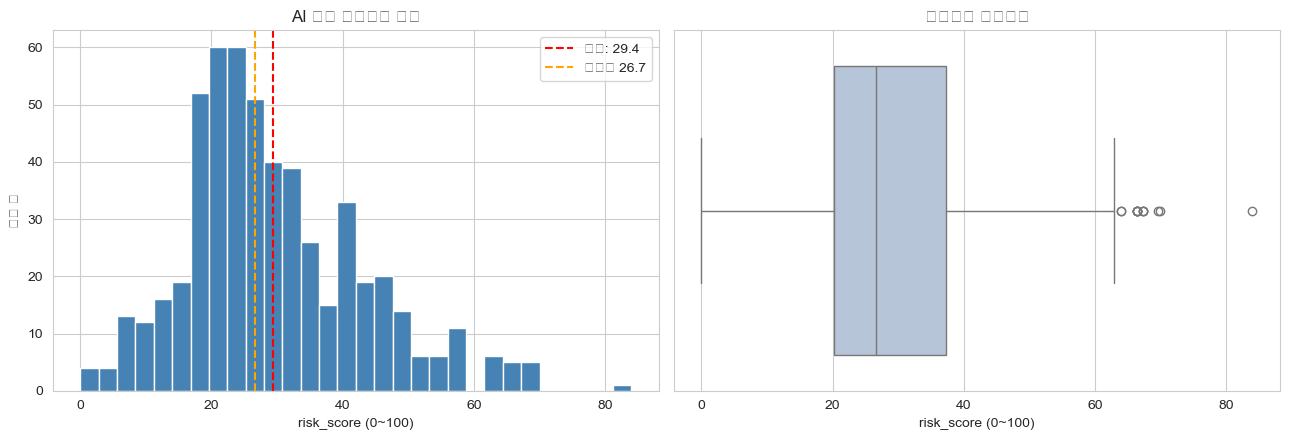

왜도(skewness): 0.78  (양수 = 오른쪽 꼬리)
상위 25% 경계(Q3): 37.3
상위 10% 경계   : 47.6


In [2]:
# (좌) 히스토그램 + 평균/중앙값 선
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["risk_score"], bins = 30, color = 'steelblue', edgecolor = 'white')
axes[0].axvline(df['risk_score'].mean(), color = 'red', linestyle = '--', label = f"평균: {df['risk_score'].mean():.1f}")
axes[0].axvline(df['risk_score'].median(), color='orange', linestyle='--',
                label=f"중앙값 {df['risk_score'].median():.1f}")
axes[0].set_title('AI 소멸 위험점수 분포')
axes[0].set_xlabel('risk_score (0~100)')
axes[0].set_ylabel('직업 수')
axes[0].legend()

# (우) 박스플롯 — 꼬리/이상치 확인
sns.boxplot(x=df['risk_score'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('위험점수 박스플롯')
axes[1].set_xlabel('risk_score (0~100)')

plt.tight_layout()
plt.show()

# 분포 특성 수치로 보강
print(f"왜도(skewness): {df['risk_score'].skew():.2f}  (양수 = 오른쪽 꼬리)")
print(f"상위 25% 경계(Q3): {df['risk_score'].quantile(0.75):.1f}")
print(f"상위 10% 경계   : {df['risk_score'].quantile(0.90):.1f}")

